1.Khai báo thư viện

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

2.Tự sinh Dl, chia ra phần train và test

In [ ]:
np.random.seed(42)
X = np.column_stack((
    np.random.randint(30, 150, 30),
    np.random.randint(1, 5, 30),
    np.random.randint(1, 15, 30)
))
y_thuc_te = 0.15 * X[:, 0] + 1.5 * X[:, 1] - 0.4 * X[:, 2] + np.random.normal(0, 2, 30)

sort_idx = np.argsort(y_thuc_te)
X = X[sort_idx]
y_thuc_te = y_thuc_te[sort_idx]
truc_x = np.arange(30)

train_idx, test_idx = train_test_split(truc_x, test_size=10, random_state=42)
train_idx = np.sort(train_idx)
test_idx = np.sort(test_idx)

X_train, y_train = X[train_idx], y_thuc_te[train_idx]
X_test, y_test = X[test_idx], y_thuc_te[test_idx]

3. làm MH bị Overfitting

In [ ]:
model_overfit = DecisionTreeRegressor(random_state=42)
model_overfit.fit(X_train, y_train)

y_train_pred = model_overfit.predict(X_train)
y_test_pred = model_overfit.predict(X_test)

4. Vẽ đường

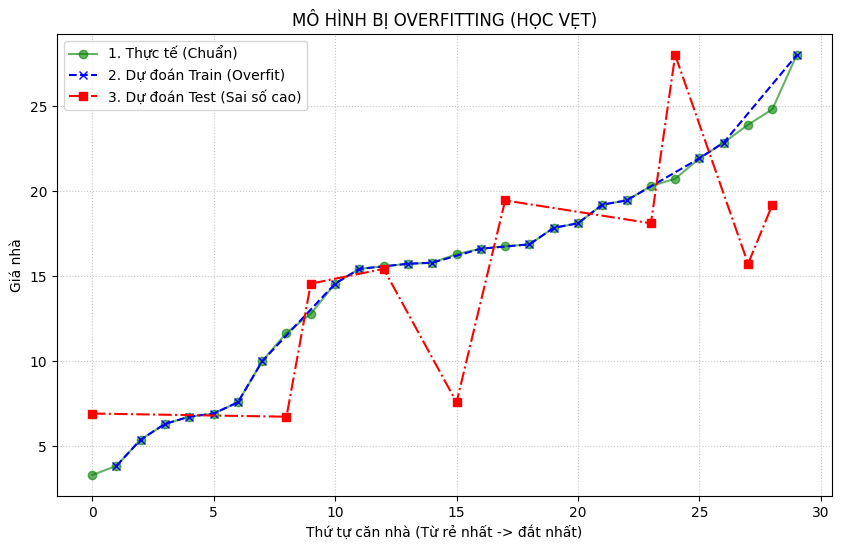

In [ ]:
plt.figure(figsize=(10, 6))

# Đường 1: Dữ liệu thực tế
plt.plot(truc_x, y_thuc_te, label='1. Thực tế (Chuẩn)', color='green', marker='o', alpha=0.6)

# Đường 2: Dự đoán trên Train (Sẽ đè lên đường thực tế do học vẹt)
plt.plot(train_idx, y_train_pred, label='2. Dự đoán Train (Overfit)', color='blue', marker='x', linestyle='--')

# Đường 3: Dự đoán trên Test (Lệch nhiều so với thực tế)
plt.plot(test_idx, y_test_pred, label='3. Dự đoán Test (Sai số cao)', color='red', marker='s', linestyle='-.')

plt.title('MÔ HÌNH BỊ OVERFITTING (HỌC VẸT)')
plt.xlabel('Thứ tự căn nhà (Từ rẻ nhất -> đắt nhất)')
plt.ylabel('Giá nhà')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

5. dùng k- fold để khắc phục

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Dùng GridSearchCV + K-Fold để tìm mô hình Ridge tốt nhất
model_kfold = GridSearchCV(Ridge(), param_grid, cv=kf)
model_kfold.fit(X_train, y_train)

best_model = model_kfold.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

6. Vẽ lại Mh


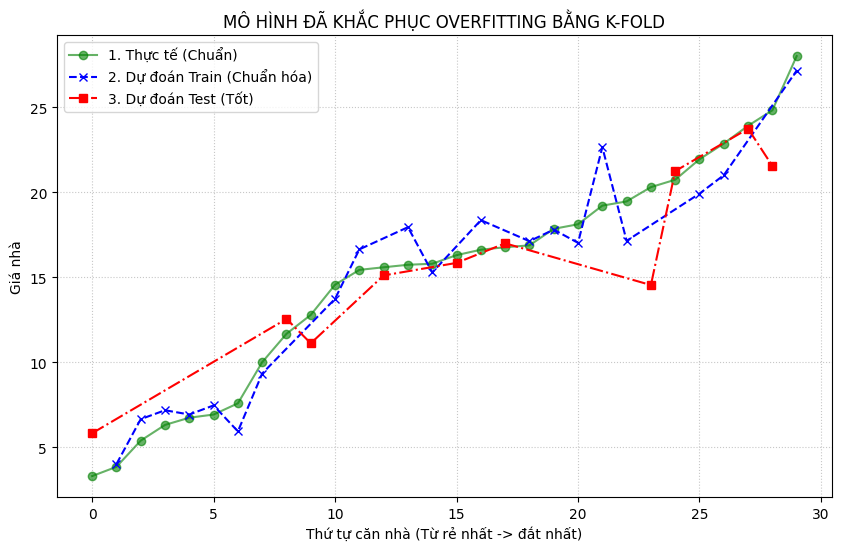

In [ ]:
plt.figure(figsize=(10, 6))

# Đường 1: Dữ liệu thực tế
plt.plot(truc_x, y_thuc_te, label='1. Thực tế (Chuẩn)', color='green', marker='o', alpha=0.6)

# Đường 2: Dự đoán trên Train (Không còn học vẹt, bám sát thực tế)
plt.plot(train_idx, y_train_pred, label='2. Dự đoán Train (Chuẩn hóa)', color='blue', marker='x', linestyle='--')

# Đường 3: Dự đoán trên Test (Dự đoán rất chính xác)
plt.plot(test_idx, y_test_pred, label='3. Dự đoán Test (Tốt)', color='red', marker='s', linestyle='-.')

plt.title('MÔ HÌNH ĐÃ KHẮC PHỤC OVERFITTING BẰNG K-FOLD')
plt.xlabel('Thứ tự căn nhà (Từ rẻ nhất -> đắt nhất)')
plt.ylabel('Giá nhà')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()